In [38]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mansiaggarwal88/diabetes-risk-prediction")

# print("Path to dataset files:", path)

c:\Users\XorsheedZanjani\diabetes_detection\diabetes_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 323k/323k [00:00<00:00, 1.29MB/s]

Extracting files...


Path to dataset files: C:\Users\XorsheedZanjani\.cache\kagglehub\datasets\mansiaggarwal88\diabetes-risk-prediction\versions\1


In [5]:
raw_data = pd.read_csv("data\diabetes_risk.csv")
raw_data.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\XorsheedZanjani\AppData\Local\Temp\ipykernel_15908\3568008886.py:1: SyntaxWarning: invalid escape sequence '\d'
  raw_data = pd.read_csv("data\diabetes_risk.csv")


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


## Data Cleaning 

In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [66]:
raw_data.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,DiabetesRisk_numeric
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,11250.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933,0.400000
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331,0.800036
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000,0.000000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000,0.000000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000,0.000000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000,0.000000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000,2.000000


In [ ]:
raw_data.nunique()
# no patient_id duplicates

patient_id                  15000
age                            58
gender                          3
city                           18
bmi                           239
family_history_diabetes         2
physical_activity_level         3
diet_type                       4
smoking_status                  3
alcohol_consumption             4
hours_sleep_per_night          73
stress_level                   10
fasting_blood_sugar           273
hba1c_level                    71
blood_pressure_systolic        89
blood_pressure_diastolic       58
waist_circumference_cm        614
income_bracket                  3
diabetes_risk                   3
DiabetesRisk_numeric            2
dtype: int64

#### Missing values 

Matplotlib is building the font cache; this may take a moment.


<Axes: >

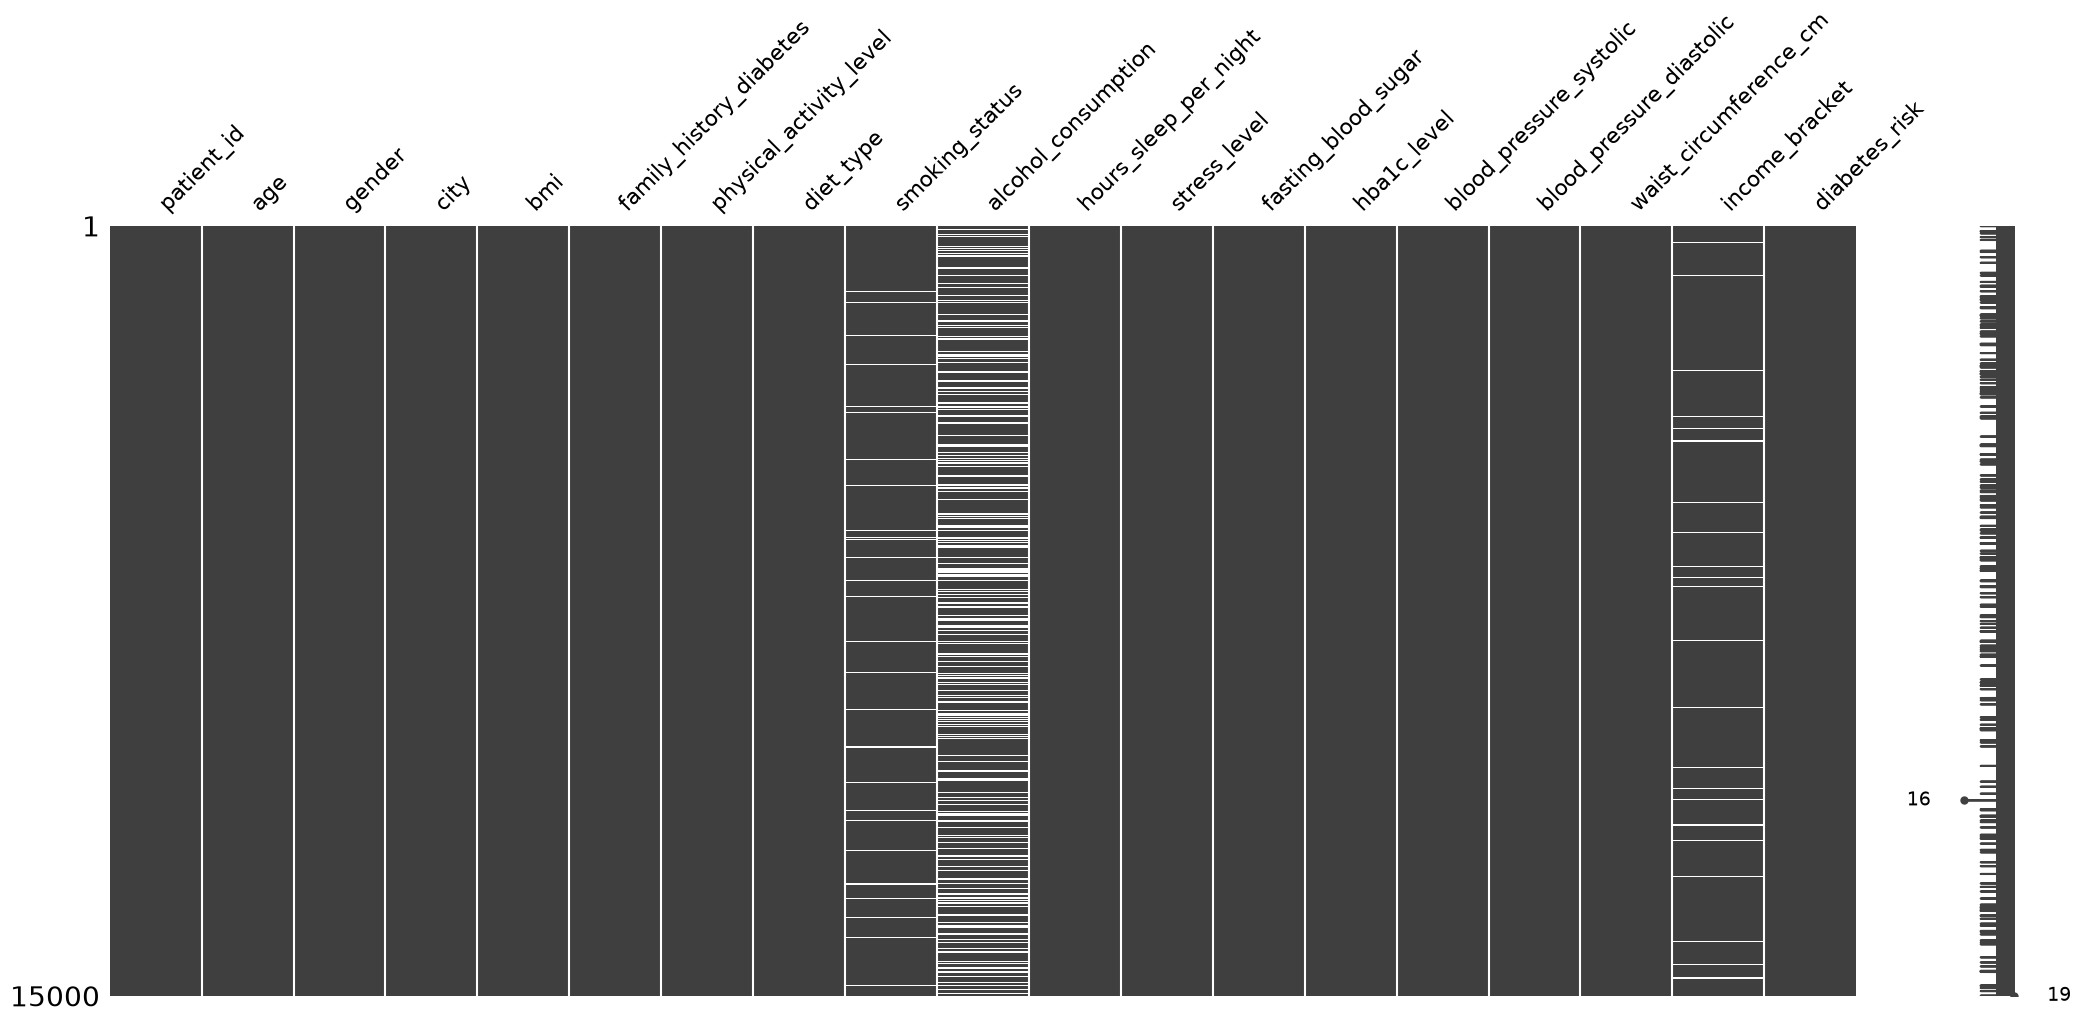

In [8]:
# Handling missing values 
import missingno as msno
msno.matrix(raw_data)

<Axes: >

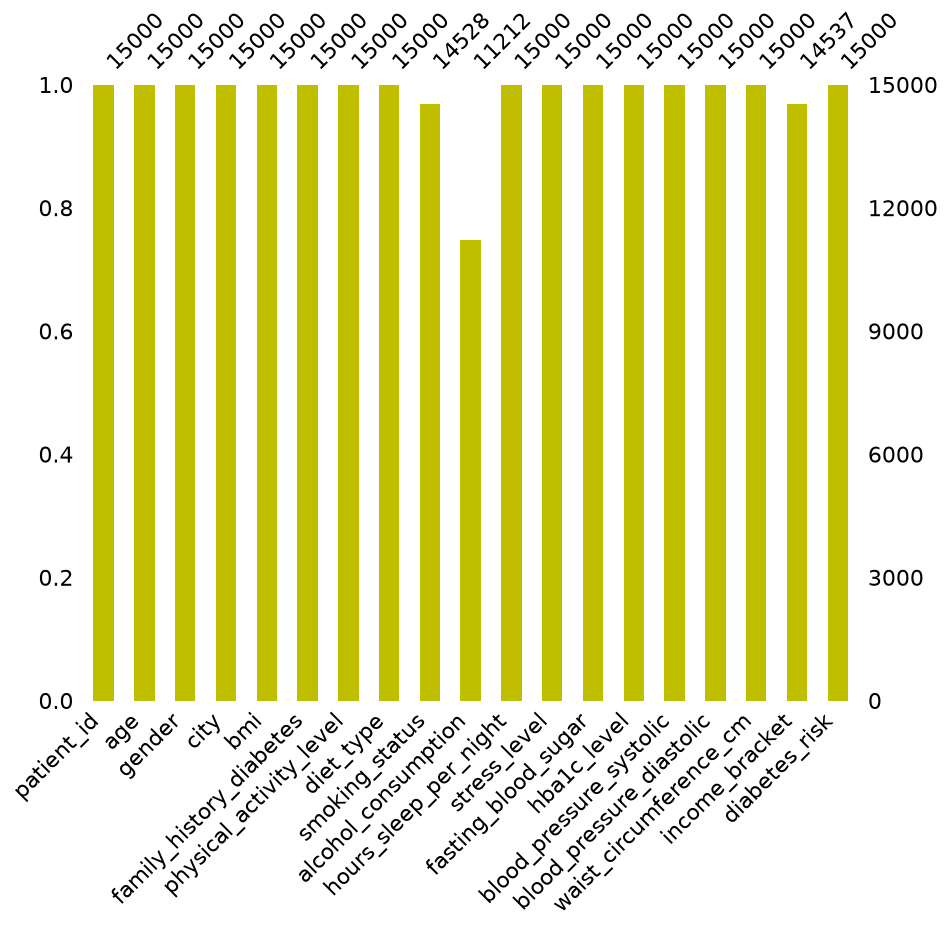

In [10]:
msno.bar(raw_data, color = 'y', figsize = (10,8))


In [ ]:
total = raw_data.isnull().sum().sort_values(ascending=False)
percent = ((raw_data.isnull().sum()/raw_data.isnull().count())*100).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data



,Total,Percent
alcohol_consumption,3788,25.253333
smoking_status,472,3.146667
income_bracket,463,3.086667
gender,0,0.000000
age,0,0.000000
patient_id,0,0.000000
city,0,0.000000
physical_activity_level,0,0.000000
family_history_diabetes,0,0.000000
diet_type,0,0.000000


In [16]:
raw_data.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


##### Observations:
- over 10% of the data is missing, so can't go ahead with row deletion 
- there is also a chance that the missing values are not random (some patients may be embarrassed to put down alchohol or smoking consumption)

Conclusion: best to go ahead with imputation to avoid bias, or missing important information 

<Axes: xlabel='alcohol_consumption'>

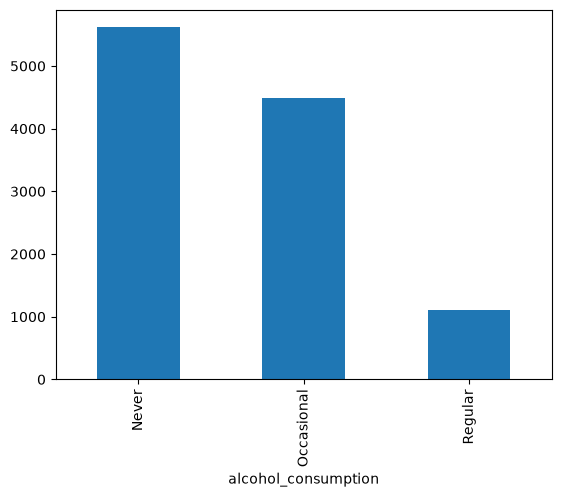

In [ ]:
# Categorical features so we need to look at distribution differently
raw_data['alcohol_consumption'].value_counts().plot(kind='bar')



<Axes: xlabel='smoking_status'>

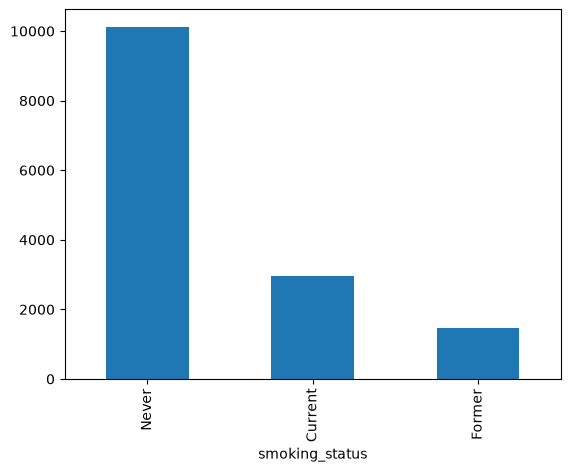

In [24]:
raw_data['smoking_status'].value_counts().plot(kind='bar')


<Axes: xlabel='income_bracket'>

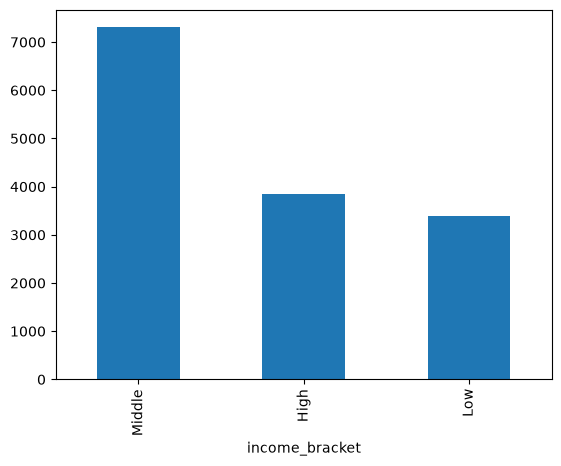

In [25]:
raw_data['income_bracket'].value_counts().plot(kind='bar')


##### Observations
- For smoking, skewed towards lower levels of smoking
- For drinking, skewed towards lower levels of drinking
- For income, skewed to middle levels of income

Conclusion: could use mode imputation for the most popular value, OR create it's own category. Perhaps the fact that patients didn't put down their levels of smoking/drinking could be an indicator (shame of admitting smoking/drinking) - and we don't want to rule this out as a random missing value. 

We can't do median imputation as these are categorical variables

- For smoking: <5-10% missing, so can go for mode imputation
- For drinking: Since we have >20% missing for alcohol would be best to create a new 'missing' category. 
- For income: <5-10% missing, so can go for mode imputation


Future: I could use KNN imputation for higher missing value precision (see this paper: https://www.sciencedirect.com/science/article/pii/S2352914823002289)

### Imputation
might have to update this to simpleimputer so it only applied to trained data, not test  bc of data leakage. for now we are just doing EDA, so will stick to this 

In [ ]:
# Simple imputation for later 
'''
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_columns)
])
'''

In [ ]:
# Mode imputing smoking, income

categorical_cols = ['smoking_status', 'income_bracket']
for col in categorical_cols:
    raw_data[col] = raw_data[col].fillna(raw_data[col].mode()[0])

In [29]:
# Missing category alcohol consumption 
raw_data['alcohol_consumption'] = raw_data['alcohol_consumption'].fillna('Missing')

In [30]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            15000 non-null  str    
 9   alcohol_consumption       15000 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

<Axes: xlabel='alcohol_consumption'>

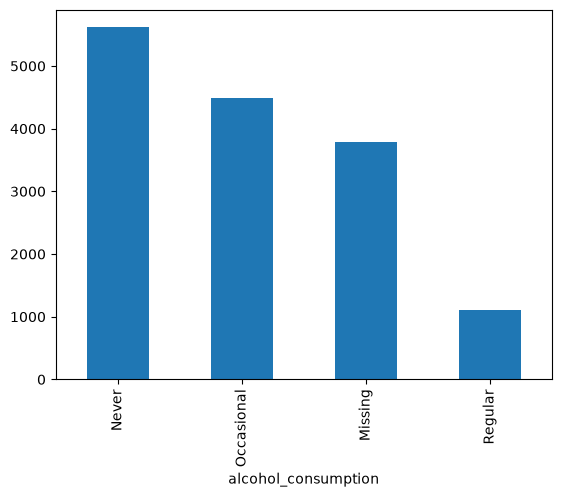

In [33]:
# Checking distribution 

raw_data['alcohol_consumption'].value_counts().plot(kind='bar')


<Axes: xlabel='smoking_status'>

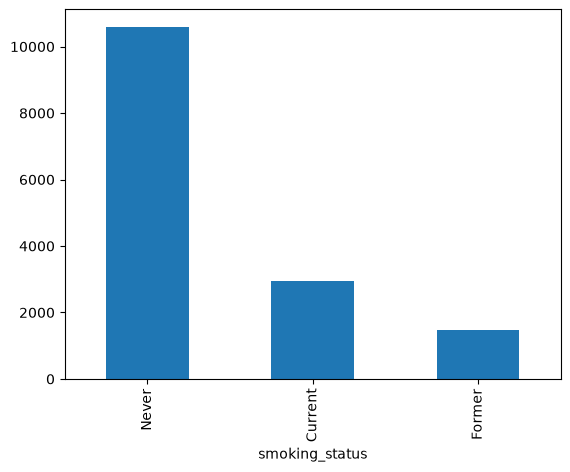

In [34]:
raw_data['smoking_status'].value_counts().plot(kind='bar')


<Axes: xlabel='income_bracket'>

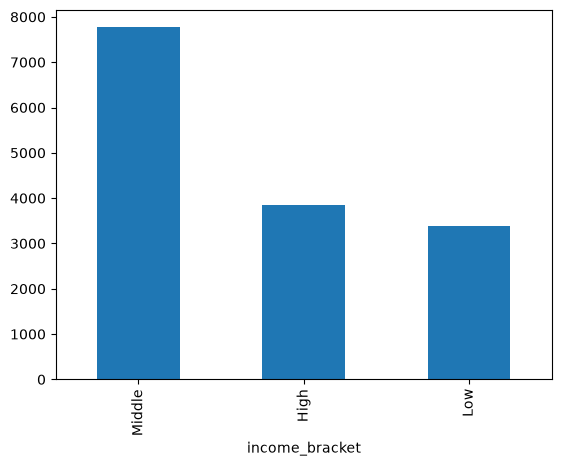

In [35]:
raw_data['income_bracket'].value_counts().plot(kind='bar')

Observation: seems like distributions are fairly similar to before for smoking and incomem

## Data Exploration

In [37]:
raw_data.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


#### Correlations

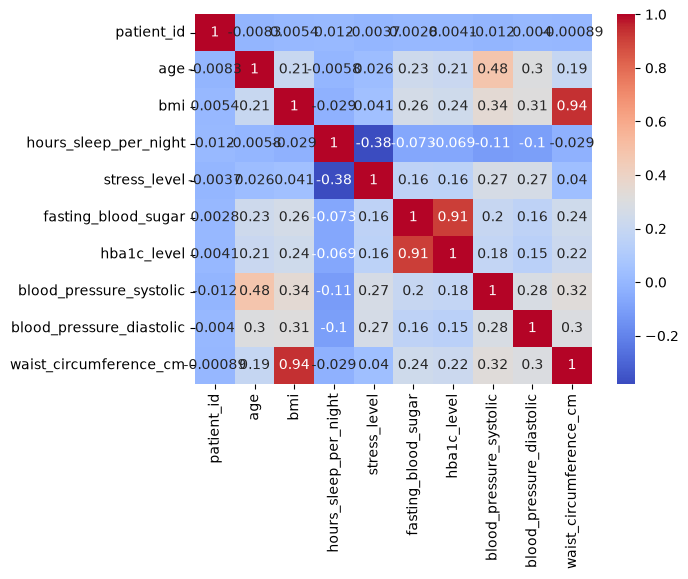

In [39]:

numeric_cols = raw_data.select_dtypes(include="number").columns

corr = raw_data[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

##### Observations 
- Very High correlation between bmi and waist_circumference 
- Very High correlation between fasting_blood_sugar and hba1c_level 
- Moderate correlation between blood_pressure_systolic and age 


In [40]:
# compare categorical and numeric values 

risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

raw_data["DiabetesRisk_numeric"] = raw_data["diabetes_risk"].map(risk_mapping)

In [56]:
# Correlation between numeric features and diabetes risk
numeric_cols = raw_data.select_dtypes(include="number").columns

raw_data[numeric_cols].corr(method="spearman")["DiabetesRisk_numeric"].sort_values(ascending=False)

DiabetesRisk_numeric        1.000000
fasting_blood_sugar         0.667222
hba1c_level                 0.663906
age                         0.279875
bmi                         0.276092
waist_circumference_cm      0.255971
blood_pressure_systolic     0.209123
blood_pressure_diastolic    0.161713
stress_level                0.092672
patient_id                  0.010930
hours_sleep_per_night      -0.043780
Name: DiabetesRisk_numeric, dtype: float64

##### Observations on correlation between numerical variables and diabetes risk
- fasting_blood_sugar, hba1c_level has a strong correlation to diabetes 

In [46]:
# Categorical features correlation with diabetes risk
col="smoking_status"
pd.crosstab(raw_data[col], raw_data["diabetes_risk"], normalize="index")

diabetes_risk,High,Low,Moderate
smoking_status,,,
Current,0.145282,0.598099,0.256619
Former,0.142174,0.590567,0.267259
Never,0.152394,0.601832,0.245775


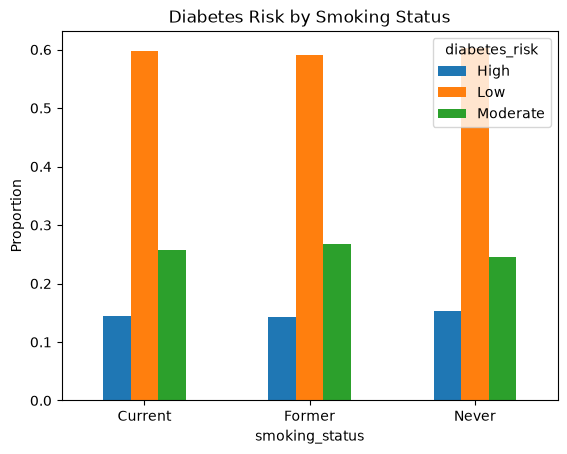

In [51]:
pd.crosstab(
    raw_data["smoking_status"],
    raw_data["diabetes_risk"],
    normalize="index"
).plot(kind="bar")

plt.ylabel("Proportion")
plt.title("Diabetes Risk by Smoking Status")
plt.xticks(rotation=0)
plt.show()

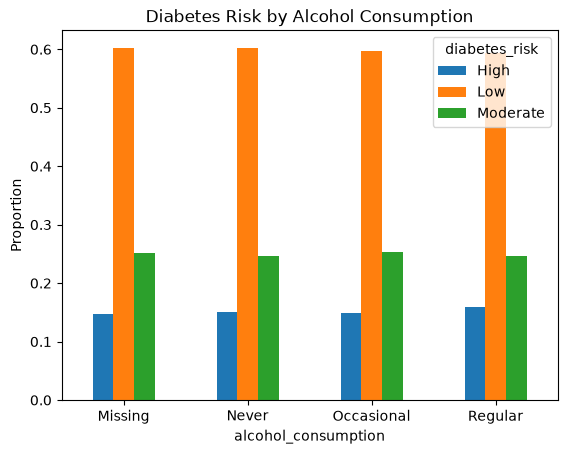

In [52]:
# Categorical features correlation with diabetes risk 
pd.crosstab(
    raw_data["alcohol_consumption"],
    raw_data["diabetes_risk"],
    normalize="index"
).plot(kind="bar")

plt.ylabel("Proportion")
plt.title("Diabetes Risk by Alcohol Consumption")
plt.xticks(rotation=0)
plt.show()

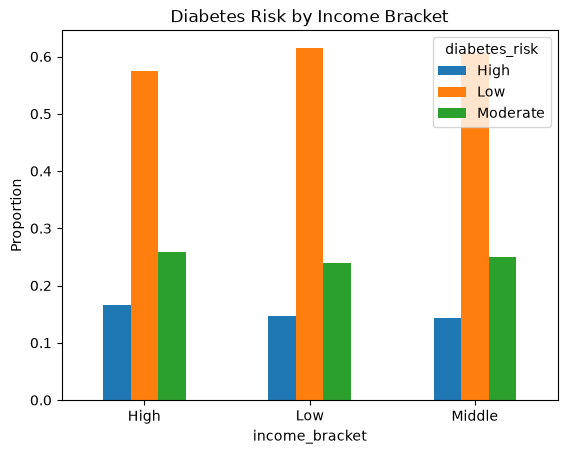

In [53]:
# Categorical features correlation with diabetes risk 
pd.crosstab(
    raw_data["income_bracket"],
    raw_data["diabetes_risk"],
    normalize="index"
).plot(kind="bar")

plt.ylabel("Proportion")
plt.title("Diabetes Risk by Income Bracket")
plt.xticks(rotation=0)
plt.show()

##### Observations on correlation between categorical variables and diabetes risk
- Smoking, income bracket and alchohol consumption have a farily even distribution across smoking status 

Conclusion: doesnt seem to be a stron relationship between these features and diabetes_risk

### Box plots 

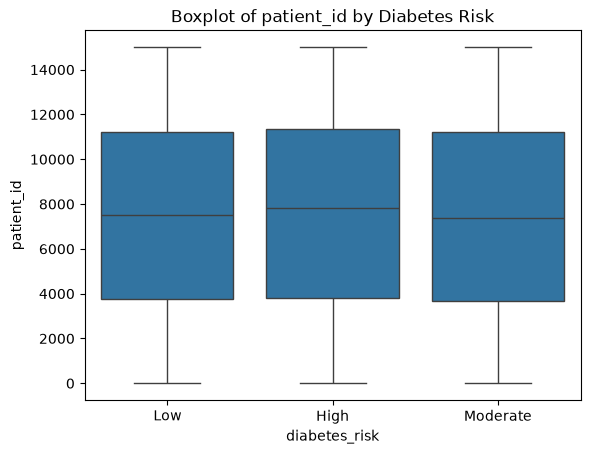

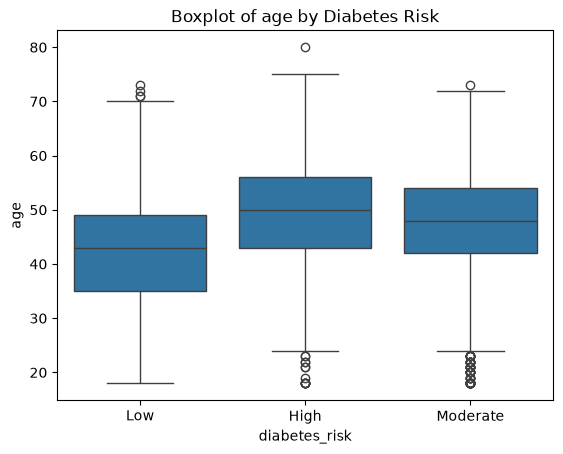

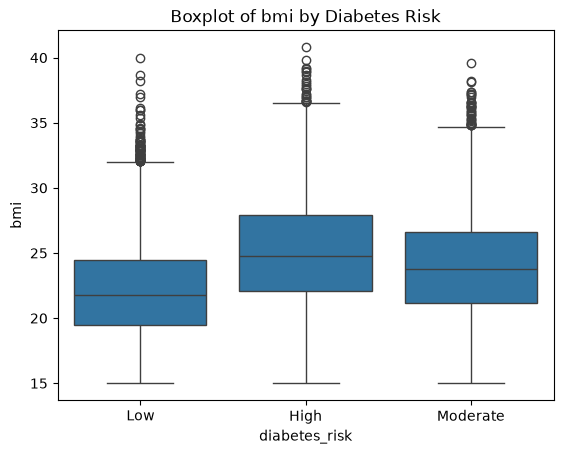

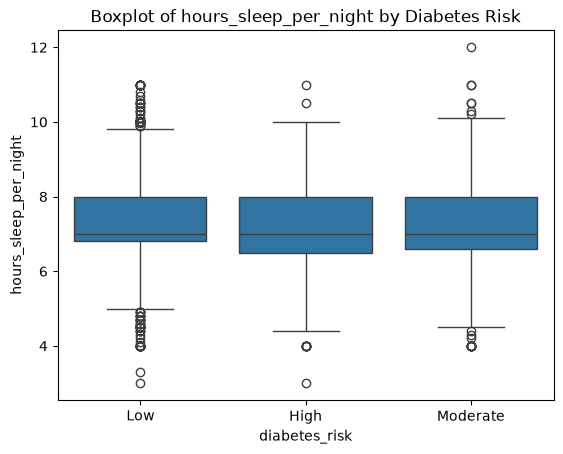

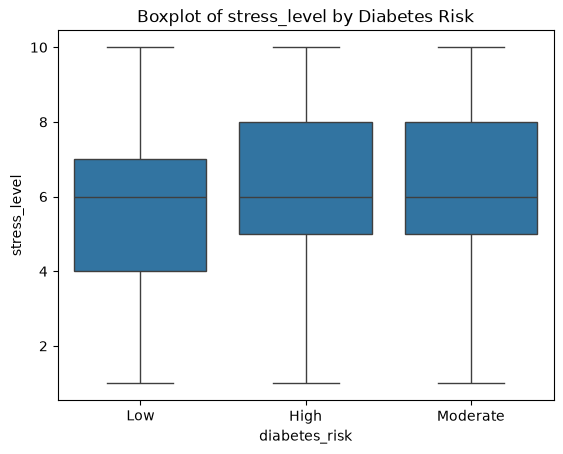

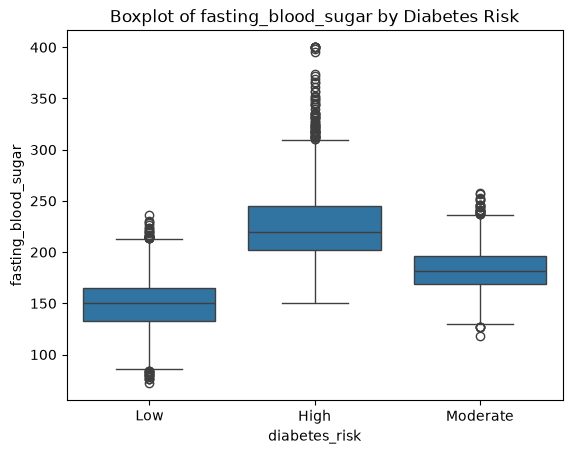

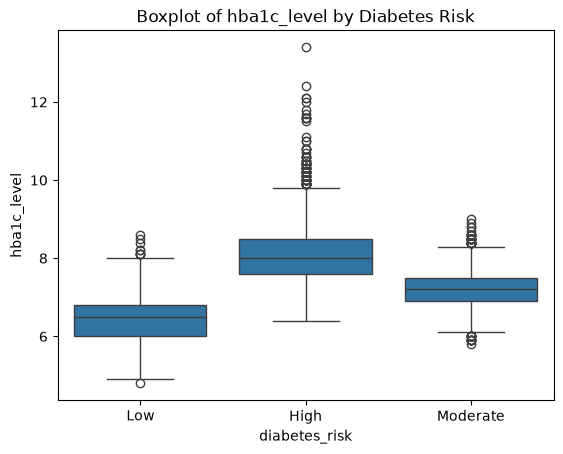

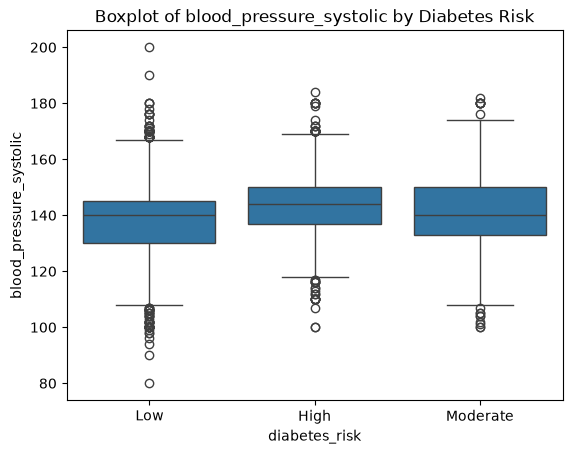

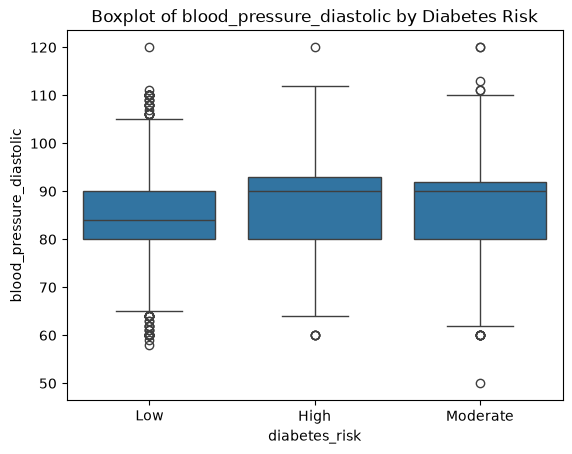

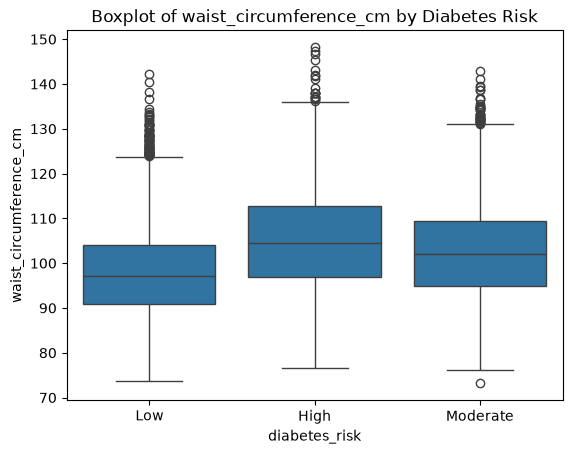

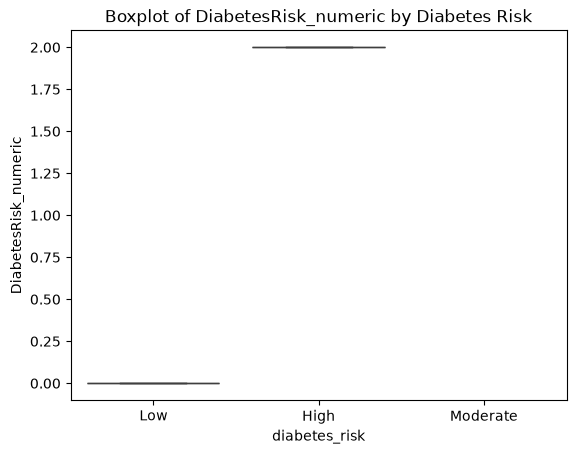

In [63]:
for num in numeric_cols:
    sns.boxplot(data=raw_data, x="diabetes_risk", y=num)
    plt.title(f"Boxplot of {num} by Diabetes Risk")
    plt.show()



##### Observations
- hbac and fasting_blood_pressure seem to be higher for higher risk of diabetes

### Diabetes risk distribution

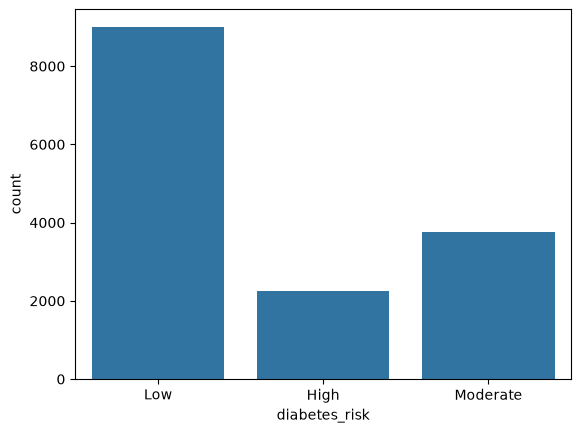

In [57]:


sns.countplot(data=raw_data, x="diabetes_risk")
plt.show()

In [58]:
raw_data["diabetes_risk"].value_counts(normalize=True) * 100

diabetes_risk
Low         60.0
Moderate    25.0
High        15.0
Name: proportion, dtype: float64

##### Observation on diabetes risk distribution 
Doesnt seem to be very imbalanced, but will need to ensure that we dont just rely on accuracy and use other metrics 

### Distribution of numeric features 

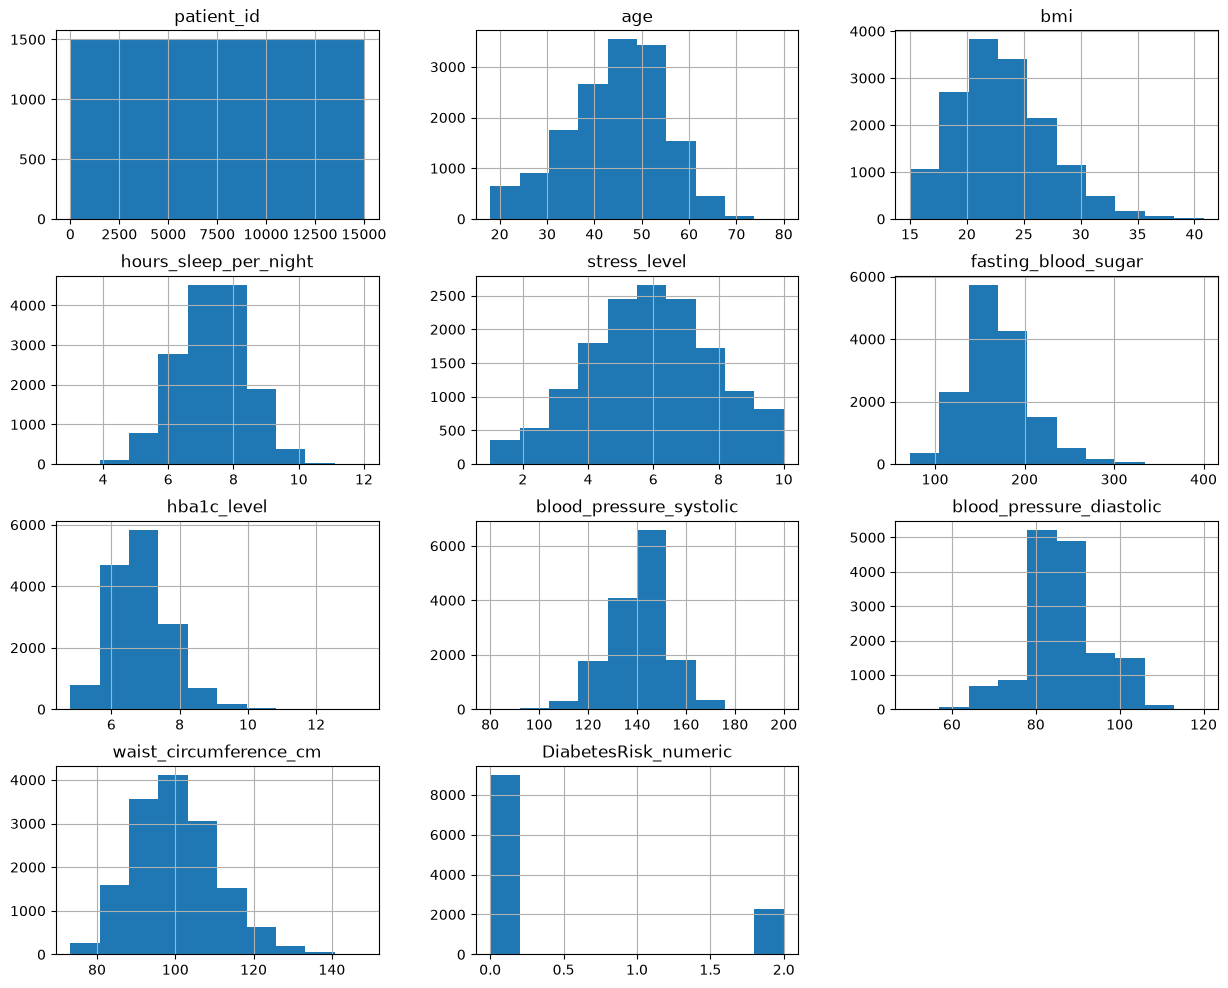

In [59]:
raw_data.hist(figsize=(15, 12))
plt.show()

#### Observations on numerical histograms:
- Skewed values like fasting_blood_sugar, hba1c_level, bmi may need to be transformed or scaled before modeling.

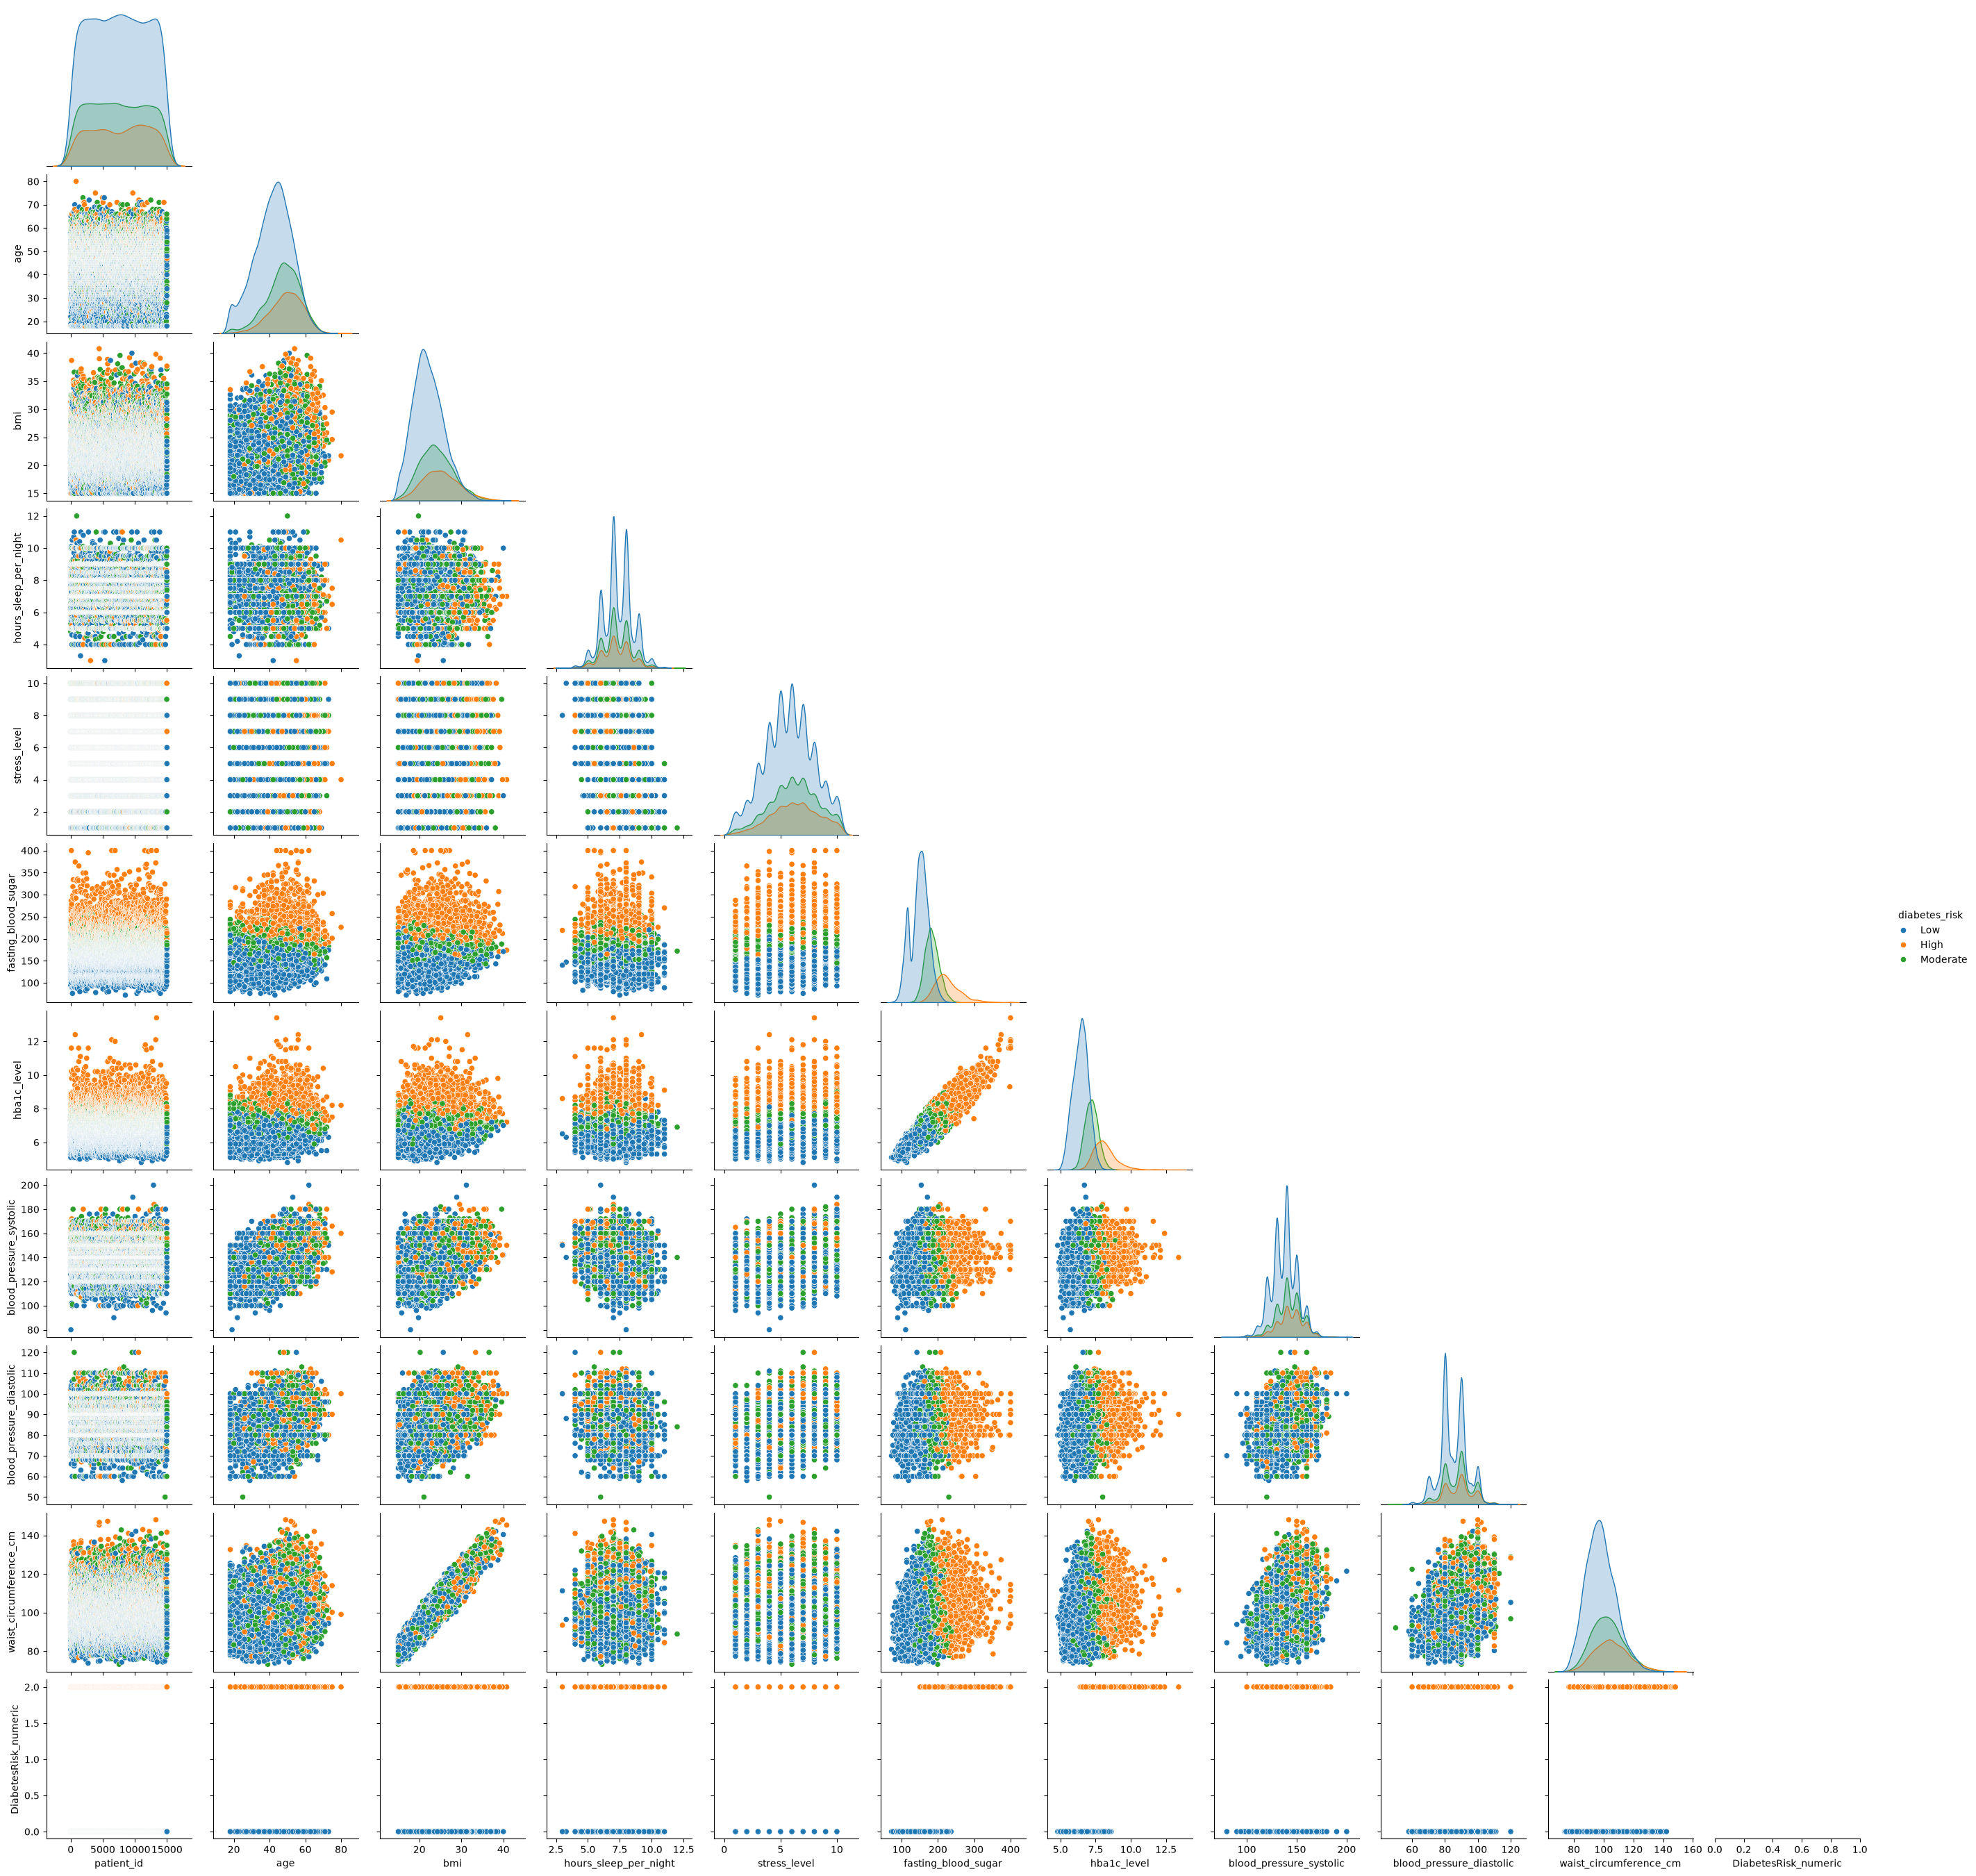

In [ ]:
## Pairplots 
# sns.pairplot(
#     raw_data,
#     hue="diabetes_risk",
#     corner=True
# )
# plt.show()
# takes about 2mins so commenting out. the plot is saved under 'pairplot.png'

#### Chi Squared

In [68]:
from scipy.stats import chi2_contingency

table = pd.crosstab(raw_data["hba1c_level"], raw_data["diabetes_risk"])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


In [70]:
table = pd.crosstab(raw_data["fasting_blood_sugar"], raw_data["diabetes_risk"])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


# Future considerations 
- Pulling in genetic data, family history 
- Simple imputer or KNN imputer